In [3]:
import pandas as pd
import matplotlib.pyplot as plt

pa = pd.read_csv("data/pa_data.csv")
temps = pd.read_csv("data/pa_temps_supplement.csv")

# Merge the new temperature columns onto the main table.
# how='left' keeps every row of pa_data; on=['station_id','year'] lines them up 1:1.
df = pa.merge(temps, on=["station_id", "year"], how="left")

print(df.shape)
df[["station_id", "station_name", "year", "tmean_spring", "tmean_april", "tmean_fall", "tmean_october"]].describe()

(10930, 71)


,year,tmean_spring,tmean_april,tmean_fall,tmean_october
count,10930.000000,10922.000000,10867.000000,10915.000000,10863.000000
mean,1966.813907,9.274904,9.399874,11.500793,11.458853
std,34.448989,1.972032,2.185491,1.786418,2.183582
min,1874.000000,1.060563,1.823333,3.571429,1.291935
25%,1941.000000,7.949592,7.952500,10.318132,10.004839
50%,1968.000000,9.392663,9.486667,11.548901,11.506667
75%,1996.000000,10.640217,10.896667,12.701667,12.936290
max,2025.000000,15.725556,18.896552,18.908197,18.863333


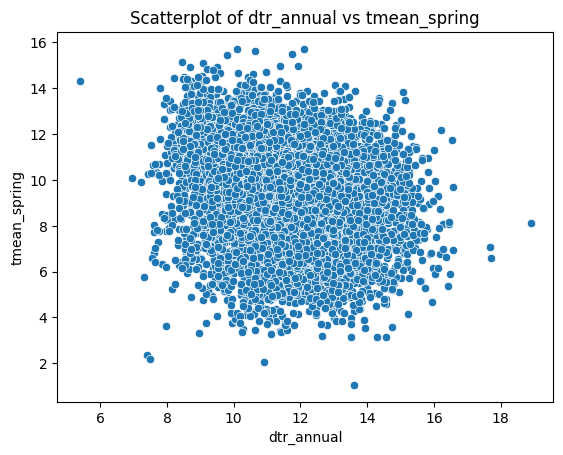

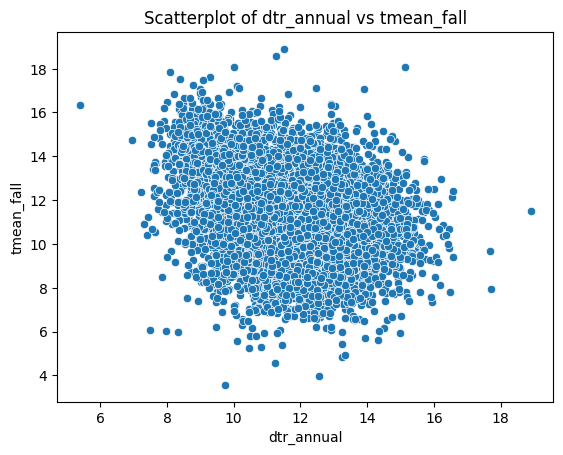

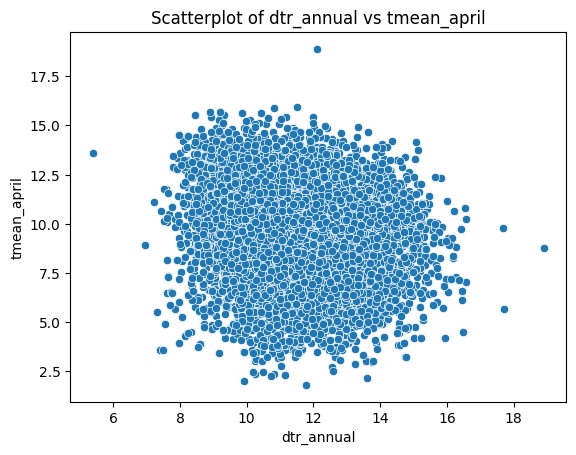

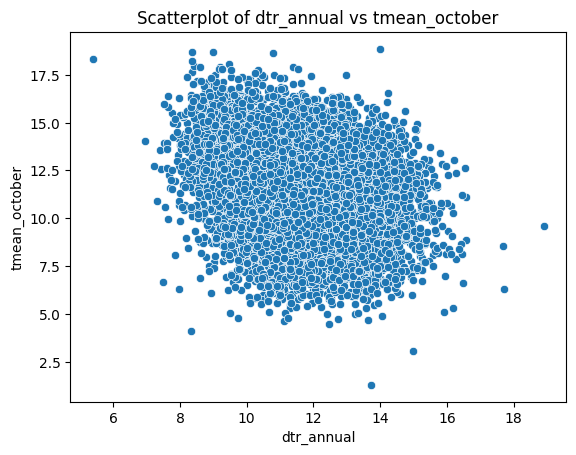

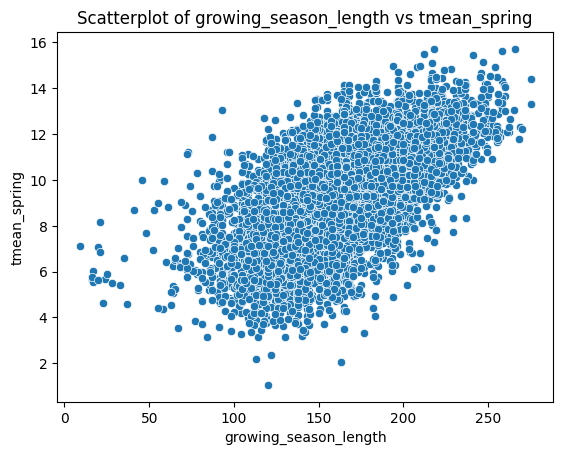

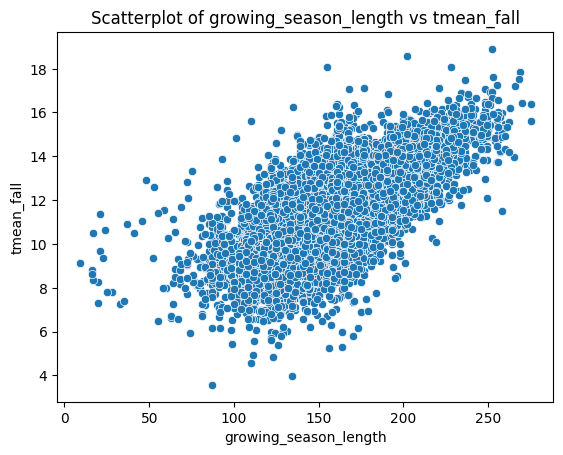

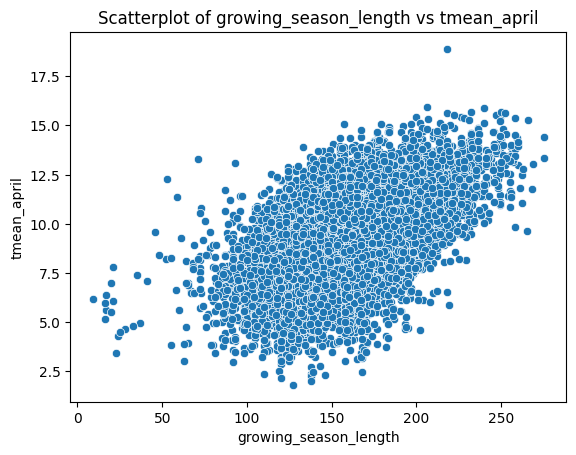

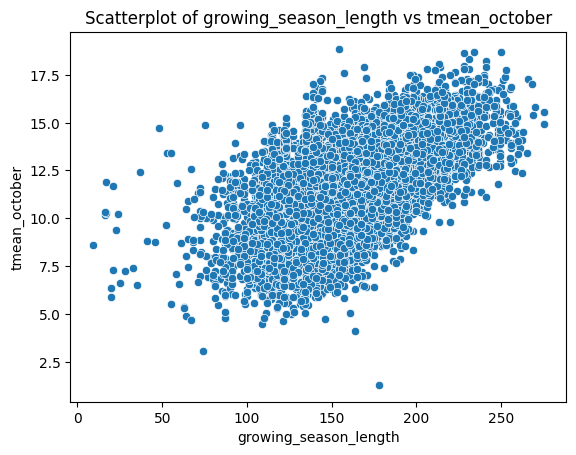

In [4]:
import seaborn as sns

def temp_plotter(data, x, y):
    sns.scatterplot(data = data, x = x, y = y)
    plt.title(f'Scatterplot of {x} vs {y}')
    plt.show()

temp_plotter(df, 'dtr_annual', 'tmean_spring')
temp_plotter(df, 'dtr_annual', 'tmean_fall')
temp_plotter(df, 'dtr_annual', 'tmean_april')
temp_plotter(df, 'dtr_annual', 'tmean_october')
temp_plotter(df, 'growing_season_length', 'tmean_spring')
temp_plotter(df, 'growing_season_length', 'tmean_fall')
temp_plotter(df, 'growing_season_length', 'tmean_april')
temp_plotter(df, 'growing_season_length', 'tmean_october')

In [5]:
df[['dtr_annual', 'growing_season_length']].describe()

,dtr_annual,growing_season_length
count,10930.000000,10930.000000
mean,11.764347,161.483440
std,1.459867,31.536052
min,5.385399,9.000000
25%,10.783305,141.250000
50%,11.829987,162.000000
75%,12.740758,181.000000
max,18.899178,275.000000


In [6]:
import statistics

df_small_dtr = df[df['dtr_annual'] < 11.83]
df_large_dtr = df[df['dtr_annual'] > 11.83]

def data_double_subset(data, variable1, variable2, int_1_s, int_1_f, int_2_s, int_2_f, int_3_s, int_3_f, var_2_low, var_2_high):
    df1 = data[data[variable1].between(int_1_s, int_1_f)]
    df1a = df1[df1[variable2] < var_2_low]
    df1b = df1[df1[variable2] > var_2_high]
    
    df2 = data[data[variable1].between(int_2_s, int_2_f)]
    df2a = df2[df2[variable2] < var_2_low]
    df2b = df2[df2[variable2] > var_2_high]
    
    df3 = data[data[variable1].between(int_3_s, int_3_f)]
    df3a = df3[df3[variable2] < var_2_low]
    df3b = df3[df3[variable2] < var_2_high]

    return df1a, df1b, df2a, df2b, df3a, df3b

def dtr_temp_variance(data, temp_var, temp_var_season_name, dtr_var, temp_int_1_s, temp_int_1_f, 
                      temp_int_2_s, temp_int_2_f, temp_int_3_s, temp_int_3_f, dtr_val_low, dtr_val_high):
    df1low, df1high, df2low, df2high, df3low, df3high = data_double_subset(data, temp_var, dtr_var, temp_int_1_s, temp_int_1_f, 
                      temp_int_2_s, temp_int_2_f, temp_int_3_s, temp_int_3_f, dtr_val_low, dtr_val_high)

    results = pd.DataFrame(columns = ['DTR Range', 'Season', 'Temp Min', 'Temp Max', '# Data Pts', 'GSL Variance'])
    results.loc[len(results)] = ['Small', temp_var_season_name, temp_int_1_s, temp_int_1_f, len(df1low), statistics.variance(df1low['growing_season_length'])]
    results.loc[len(results)] = ['Small', temp_var_season_name, temp_int_2_s, temp_int_2_f, len(df2low), statistics.variance(df2low['growing_season_length'])]
    results.loc[len(results)] = ['Small', temp_var_season_name, temp_int_3_s, temp_int_3_f, len(df3low), statistics.variance(df3low['growing_season_length'])]
    results.loc[len(results)] = ['Large', temp_var_season_name, temp_int_1_s, temp_int_1_f, len(df1high), statistics.variance(df1high['growing_season_length'])]
    results.loc[len(results)] = ['Large', temp_var_season_name, temp_int_2_s, temp_int_2_f, len(df2high), statistics.variance(df2high['growing_season_length'])]
    results.loc[len(results)] = ['Large', temp_var_season_name, temp_int_3_s, temp_int_3_f, len(df3high), statistics.variance(df3high['growing_season_length'])]
    
    print(results)

In [7]:
dtr_temp_variance(df, 'tmean_spring', 'Spring', 'dtr_annual', 0,9.2,9.2,11,11,19, 10.783, 12.74)
dtr_temp_variance(df, 'tmean_fall', 'Fall', 'dtr_annual', 0,11.5,11.5,13.2,13.2,19, 10.783, 12.74)
dtr_temp_variance(df, 'tmean_april', 'April', 'dtr_annual', 0,9.2,9.2,11,11,19, 10.783, 12.74)
dtr_temp_variance(df, 'tmean_october', 'October', 'dtr_annual', 0,11.3,11.3,13.3,13.3,19, 10.783, 12.74)

  DTR Range  Season  Temp Min  Temp Max  # Data Pts  GSL Variance
0     Small  Spring       0.0       9.2         967    635.642897
1     Small  Spring       9.2      11.0         944    462.100936
2     Small  Spring      11.0      19.0         819    643.811252
3     Large  Spring       0.0       9.2        1464    642.053505
4     Large  Spring       9.2      11.0         915    421.972790
5     Large  Spring      11.0      19.0        1749    721.980077
  DTR Range Season  Temp Min  Temp Max  # Data Pts  GSL Variance
0     Small   Fall       0.0      11.5         950    529.918834
1     Small   Fall      11.5      13.2         922    362.532487
2     Small   Fall      13.2      19.0         858    532.630508
3     Large   Fall       0.0      11.5        1671    634.596923
4     Large   Fall      11.5      13.2         856    427.875712
5     Large   Fall      13.2      19.0        1598    673.282273
  DTR Range Season  Temp Min  Temp Max  # Data Pts  GSL Variance
0     Small  April

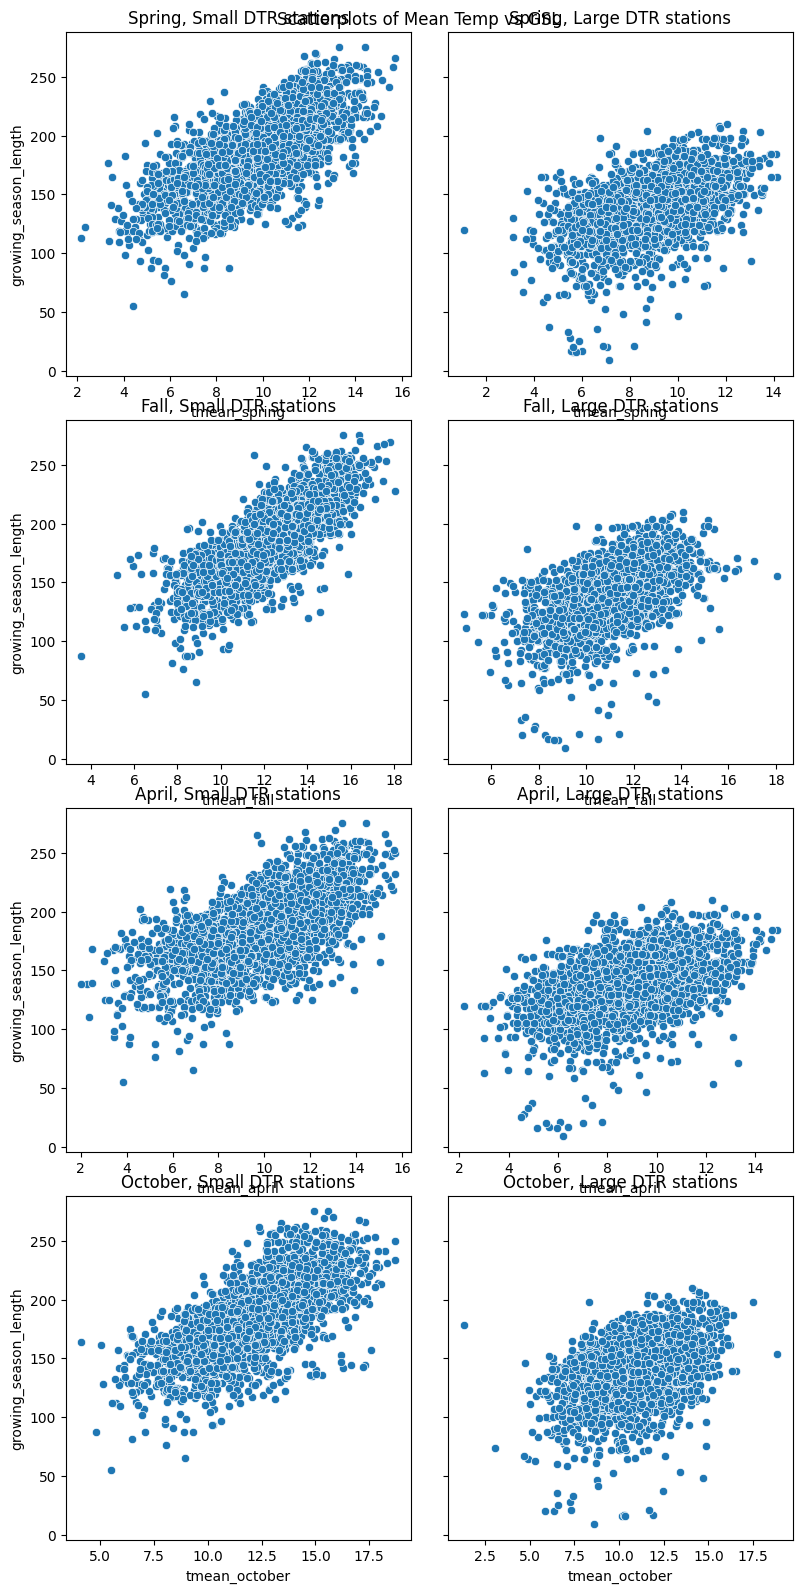

In [8]:
df_1q_dtr = df[df['dtr_annual'].between(5.385, 10.783)]
df_4q_dtr = df[df['dtr_annual'].between(12.74, 18.89)]

fig, axs = plt.subplots(4,2, sharey = True, figsize = (8, 16))
fig.suptitle('Scatterplots of Mean Temp vs GSL')
fig.tight_layout()
axs[0,0] = sns.scatterplot(data = df_1q_dtr, x = 'tmean_spring', y = 'growing_season_length', ax=axs[0,0])
axs[0,0].set_title('Spring, Small DTR stations')
axs[0,1] = sns.scatterplot(data = df_4q_dtr, x = 'tmean_spring', y = 'growing_season_length', ax=axs[0,1])
axs[0,1].set_title('Spring, Large DTR stations')
axs[1,0] = sns.scatterplot(data = df_1q_dtr, x = 'tmean_fall', y = 'growing_season_length', ax=axs[1,0])
axs[1,0].set_title('Fall, Small DTR stations')
axs[1,1] = sns.scatterplot(data = df_4q_dtr, x = 'tmean_fall', y = 'growing_season_length', ax=axs[1,1])
axs[1,1].set_title('Fall, Large DTR stations')
axs[2,0] = sns.scatterplot(data = df_1q_dtr, x = 'tmean_april', y = 'growing_season_length', ax=axs[2,0])
axs[2,0].set_title('April, Small DTR stations')
axs[2,1] = sns.scatterplot(data = df_4q_dtr, x = 'tmean_april', y = 'growing_season_length', ax=axs[2,1])
axs[2,1].set_title('April, Large DTR stations')
axs[3,0] = sns.scatterplot(data = df_1q_dtr, x = 'tmean_october', y = 'growing_season_length', ax=axs[3,0])
axs[3,0].set_title('October, Small DTR stations')
axs[3,1] = sns.scatterplot(data = df_4q_dtr, x = 'tmean_october', y = 'growing_season_length', ax=axs[3,1])
axs[3,1].set_title('October, Large DTR stations')
plt.show()

In [9]:
df_small_dtr['growing_season_length'].describe()

count    5465.000000
mean      175.461665
std        30.027678
min        55.000000
25%       157.000000
50%       175.000000
75%       194.000000
max       275.000000
Name: growing_season_length, dtype: float64

In [10]:
df_large_dtr['growing_season_length'].describe()

count    5465.000000
mean      147.505215
std        26.395316
min         9.000000
25%       130.000000
50%       150.000000
75%       166.000000
max       222.000000
Name: growing_season_length, dtype: float64

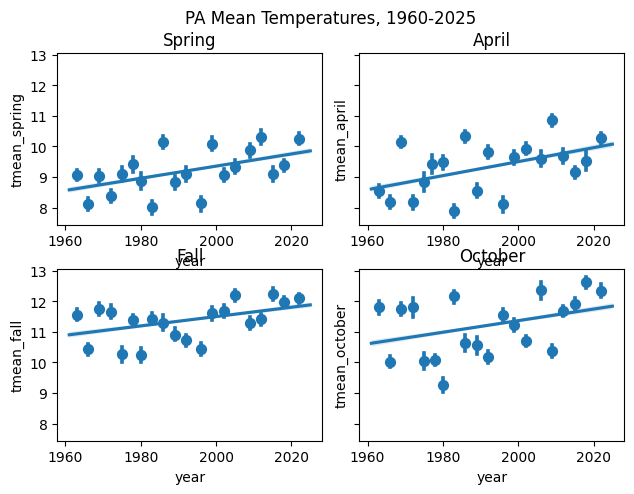

In [18]:
import seaborn as sns
fig, axs = plt.subplots(2,2, sharey= True)
fig.suptitle("PA Mean Temperatures, 1960-2025")
fig.tight_layout()
axs[0,0] = sns.regplot(df[df['year'] >1960], x='year', y='tmean_spring', x_bins = 20, ax= axs[0,0])
axs[0,0].set_title('Spring')
axs[0,1] = sns.regplot(df[df['year'] >1960], x='year', y='tmean_april', x_bins = 20, ax= axs[0,1])
axs[0,1].set_title('April')
axs[1,0] = sns.regplot(df[df['year'] >1960], x='year', y='tmean_fall', x_bins = 20, ax= axs[1,0])
axs[1,0].set_title('Fall')
axs[1,1] = sns.regplot(df[df['year'] >1960], x='year', y='tmean_october', x_bins = 20, ax= axs[1,1])
axs[1,1].set_title('October')
plt.show()